In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle


In [2]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [3]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5')
ds1_annual = catalog.open_dataset(id=catalog.Items[18].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
ds1_monthly = catalog.open_dataset(id=catalog.Items[27].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_annual = {'parent': {'domain': config, 'gridT': ds1_annual}}
dt_global_annual = NEMODataTree.from_datasets(datasets = datasets_annual)
datasets_monthly = {'parent': {'domain': config, 'gridT': ds1_monthly}}
dt_global_monthly = NEMODataTree.from_datasets(datasets = datasets_monthly)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_annual = dt_global_annual.clip_grid(grid='/gridT', bbox=bbox)
dt_monthly = dt_global_monthly.clip_grid(grid='/gridT', bbox=bbox)

# Convert to datasets
ds_annual = (dt_annual['/gridT']).dataset
ds_monthly = (dt_monthly['/gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/U1y
              Title: eORCA1 ERA5v1 NPD U1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at U-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/V1y
              Title: eORCA1 ERA5v1 NPD V1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global oc

In [4]:
amplitudes = xr.open_dataset('AMPLITUDES.nc')['thetao_con']
amplitudes = amplitudes.swap_dims({'k': 'deptht'})

In [ ]:
## 50m

salinity_50 = (ds_annual['so_abs'].sel(deptht = 50, method = 'nearest')).compute()
salinity_50['time_counter'] = salinity_50['time_counter'].dt.year
amplitude_50 = amplitudes.sel(deptht = 50, method = 'nearest')

ny, nx = amplitude_50.sizes['j'], amplitude_50.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_50.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_50.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p
    print(y_idx)


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_50['j'],
        'i': amplitude_50['i'], 'gphit': (('j', 'i'), amplitude_50['gphit'].values),
        'glamt': (('j', 'i'), amplitude_50['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_50['j'],
        'i': amplitude_50['i'], 'gphit': (('j', 'i'), amplitude_50['gphit'].values),
        'glamt': (('j', 'i'), amplitude_50['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 50m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

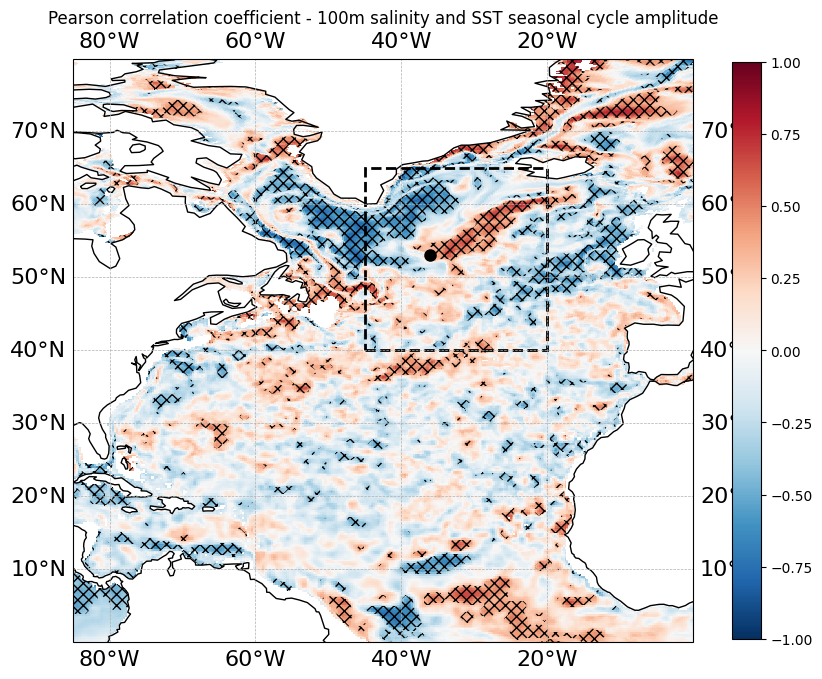

In [11]:
## 100m

salinity_100 = (ds_annual['so_abs'].sel(deptht = 100, method = 'nearest')).compute()
salinity_100['time_counter'] = salinity_100['time_counter'].dt.year
amplitude_100 = amplitudes.sel(deptht = 100, method = 'nearest')

ny, nx = amplitude_100.sizes['j'], amplitude_100.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_100.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_100.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_100['j'],
        'i': amplitude_100['i'], 'gphit': (('j', 'i'), amplitude_100['gphit'].values),
        'glamt': (('j', 'i'), amplitude_100['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_100['j'],
        'i': amplitude_100['i'], 'gphit': (('j', 'i'), amplitude_100['gphit'].values),
        'glamt': (('j', 'i'), amplitude_100['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 100m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

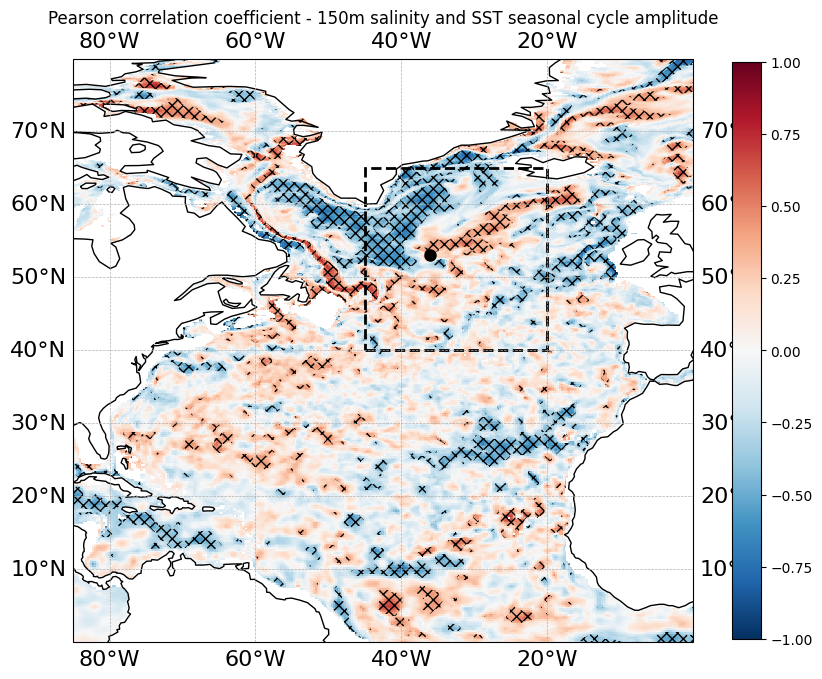

In [12]:
## 150m

salinity_150 = (ds_annual['so_abs'].sel(deptht = 150, method = 'nearest')).compute()
salinity_150['time_counter'] = salinity_150['time_counter'].dt.year
amplitude_150 = amplitudes.sel(deptht = 150, method = 'nearest')

ny, nx = amplitude_150.sizes['j'], amplitude_150.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_150.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_150.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_150['j'],
        'i': amplitude_150['i'], 'gphit': (('j', 'i'), amplitude_150['gphit'].values),
        'glamt': (('j', 'i'), amplitude_150['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_150['j'],
        'i': amplitude_150['i'], 'gphit': (('j', 'i'), amplitude_150['gphit'].values),
        'glamt': (('j', 'i'), amplitude_150['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 150m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

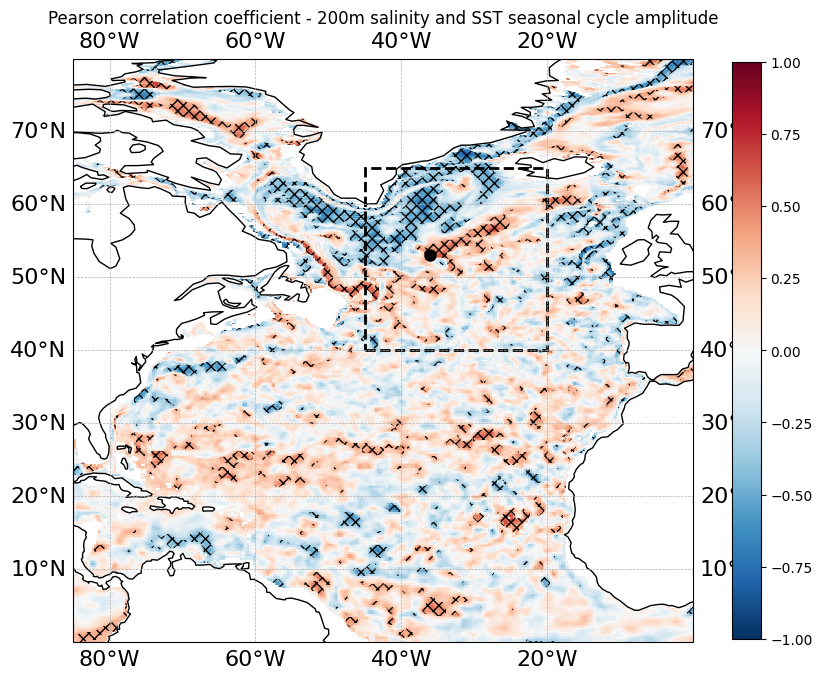

In [5]:
## 200m

salinity_200 = (ds_annual['so_abs'].sel(deptht = 200, method = 'nearest')).compute()
salinity_200['time_counter'] = salinity_200['time_counter'].dt.year
amplitude_200 = amplitudes.sel(deptht = 200, method = 'nearest')

ny, nx = amplitude_200.sizes['j'], amplitude_200.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_200.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_200.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_200['j'],
        'i': amplitude_200['i'], 'gphit': (('j', 'i'), amplitude_200['gphit'].values),
        'glamt': (('j', 'i'), amplitude_200['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_200['j'],
        'i': amplitude_200['i'], 'gphit': (('j', 'i'), amplitude_200['gphit'].values),
        'glamt': (('j', 'i'), amplitude_200['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 200m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

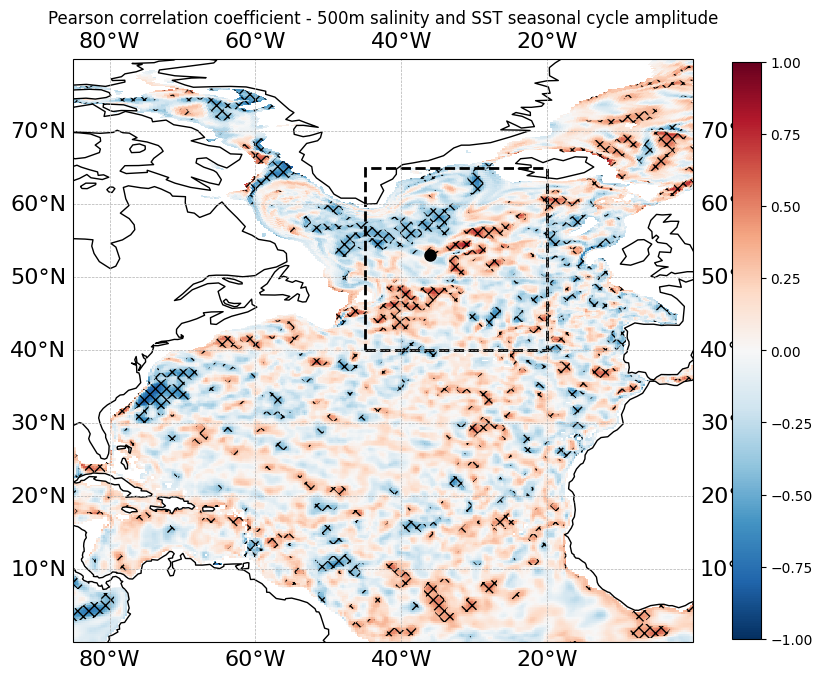

In [6]:
## 500m

salinity_500 = (ds_annual['so_abs'].sel(deptht = 500, method = 'nearest')).compute()
salinity_500['time_counter'] = salinity_500['time_counter'].dt.year
amplitude_500 = amplitudes.sel(deptht = 500, method = 'nearest')

ny, nx = amplitude_500.sizes['j'], amplitude_500.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_500.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_500.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_500['j'],
        'i': amplitude_500['i'], 'gphit': (('j', 'i'), amplitude_500['gphit'].values),
        'glamt': (('j', 'i'), amplitude_500['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_500['j'],
        'i': amplitude_500['i'], 'gphit': (('j', 'i'), amplitude_500['gphit'].values),
        'glamt': (('j', 'i'), amplitude_500['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 500m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

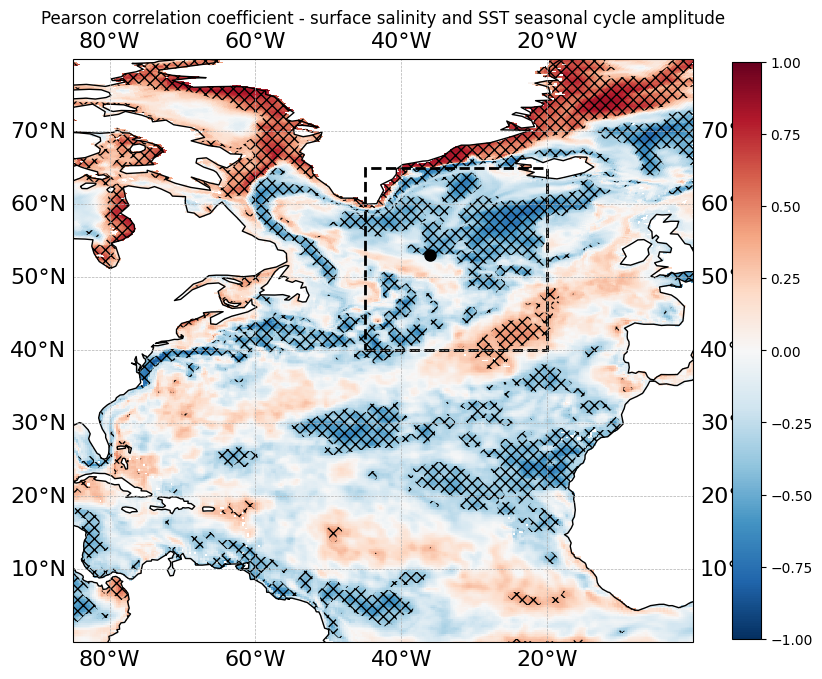

In [7]:
## Surface

salinity_0 = (ds_annual['so_abs'].sel(deptht = 0, method = 'nearest')).compute()
salinity_0['time_counter'] = salinity_0['time_counter'].dt.year
amplitude_0 = amplitudes.sel(deptht = 0, method = 'nearest')

ny, nx = amplitude_0.sizes['j'], amplitude_0.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_0.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_0.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_0['j'],
        'i': amplitude_0['i'], 'gphit': (('j', 'i'), amplitude_0['gphit'].values),
        'glamt': (('j', 'i'), amplitude_0['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_0['j'],
        'i': amplitude_0['i'], 'gphit': (('j', 'i'), amplitude_0['gphit'].values),
        'glamt': (('j', 'i'), amplitude_0['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - surface salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [ ]:
## 1km

salinity_1000 = (ds_annual['so_abs'].sel(deptht = 1000, method = 'nearest')).compute()
salinity_1000['time_counter'] = salinity_1000['time_counter'].dt.year
amplitude_1000 = amplitudes.sel(deptht = 1000, method = 'nearest')

ny, nx = amplitude_1000.sizes['j'], amplitude_1000.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_1000.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_1000.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_1000['j'],
        'i': amplitude_1000['i'], 'gphit': (('j', 'i'), amplitude_1000['gphit'].values),
        'glamt': (('j', 'i'), amplitude_1000['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_1000['j'],
        'i': amplitude_1000['i'], 'gphit': (('j', 'i'), amplitude_1000['gphit'].values),
        'glamt': (('j', 'i'), amplitude_1000['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 1000m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [ ]:
## 2km

salinity_2000 = (ds_annual['so_abs'].sel(deptht = 2000, method = 'nearest')).compute()
salinity_2000['time_counter'] = salinity_2000['time_counter'].dt.year
amplitude_2000 = amplitudes.sel(deptht = 2000, method = 'nearest')

ny, nx = amplitude_2000.sizes['j'], amplitude_2000.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude_2000.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_2000.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        r, p = pearsonr(sal_ts, amp_ts)
        r_data[y_idx, x_idx] = r
        p_data[y_idx, x_idx] = p


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_2000['j'],
        'i': amplitude_2000['i'], 'gphit': (('j', 'i'), amplitude_2000['gphit'].values),
        'glamt': (('j', 'i'), amplitude_2000['glamt'].values)}, name='slope',
        attrs={'description': 'Correlation coefficient of salinity and amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude_2000['j'],
        'i': amplitude_2000['i'], 'gphit': (('j', 'i'), amplitude_2000['gphit'].values),
        'glamt': (('j', 'i'), amplitude_2000['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for Correlation coefficient of salinity and amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearson correlation coefficient - 2000m salinity and SST seasonal cycle amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)